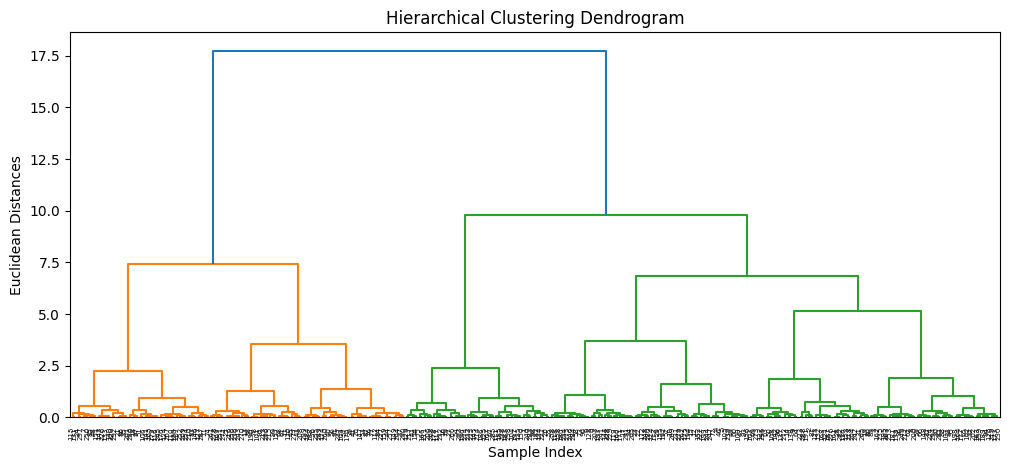


Training Agglomerative Clustering (Ward Linkage)...
Silhouette Score: 0.4407


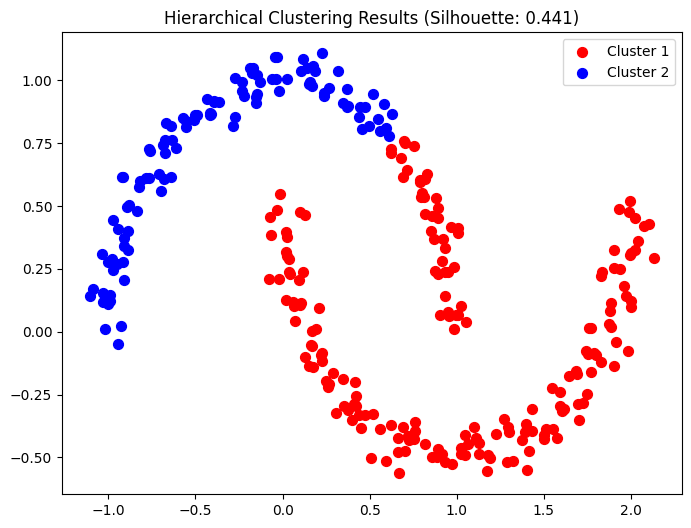

In [1]:


import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score

# --- 1. Data Generation ---
# Using make_moons to show where Hierarchical might differ from K-Means
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# --- 2. Dendrogram Visualization ---
plt.figure(figsize=(12, 5))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distances")
# 'ward' minimizes the variance of the clusters being merged
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.show()

# --- 3. Model Training ---
# Based on the dendrogram, let's say we choose 2 clusters
print("\nTraining Agglomerative Clustering (Ward Linkage)...")
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

# --- 4. Evaluation ---
score = silhouette_score(X, y_hc)
print(f"Silhouette Score: {score:.4f}")

# --- 5. Visualization ---
plt.figure(figsize=(8, 6))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=50, c='blue', label='Cluster 2')
plt.title(f'Hierarchical Clustering Results (Silhouette: {score:.3f})')
plt.legend()
plt.show()